In [30]:
import pandas as pd

df = pd.read_csv("titanic_clean.csv")
print(df.shape)
print(df.head())

(889, 10)
   survived  pclass     sex   age  sibsp  parch     fare embarked    who  \
0         0       3    male  22.0      1      0   7.2500        S    man   
1         1       1  female  38.0      1      0  71.2833        C  woman   
2         1       3  female  26.0      0      0   7.9250        S  woman   
3         1       1  female  35.0      1      0  53.1000        S  woman   
4         0       3    male  35.0      0      0   8.0500        S    man   

   alone  
0  False  
1  False  
2   True  
3  False  
4   True  


In [31]:
label_maps = {
    "sex": {"male": 0, "female": 1},
    "embarked": {"S": 0, "C": 1, "Q": 2},
    "who": {"man": 0, "woman": 1, "child": 2},
    "alone": {True: 1, False: 0}
}

for col, mapping in label_maps.items():
    df[col] = df[col].map(mapping)

print("Label maps used:")
for col, mapping in label_maps.items():
    print(f"  {col}: {mapping}")

print()
print(df.head())

Label maps used:
  sex: {'male': 0, 'female': 1}
  embarked: {'S': 0, 'C': 1, 'Q': 2}
  who: {'man': 0, 'woman': 1, 'child': 2}
  alone: {True: 1, False: 0}

   survived  pclass  sex   age  sibsp  parch     fare  embarked  who  alone
0         0       3    0  22.0      1      0   7.2500         0    0      0
1         1       1    1  38.0      1      0  71.2833         1    1      0
2         1       3    1  26.0      0      0   7.9250         0    1      1
3         1       1    1  35.0      1      0  53.1000         0    1      0
4         0       3    0  35.0      0      0   8.0500         0    0      1


In [32]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["survived"])
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print()
print("Train survival rate:", y_train.mean())
print("Test survival rate:", y_test.mean())
print("Full dataset survival rate:", y.mean())

Train shape: (711, 9)
Test shape: (178, 9)

Train survival rate: 0.38255977496483823
Test survival rate: 0.38202247191011235
Full dataset survival rate: 0.38245219347581555


In [33]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

categorical_cols = ["sex", "embarked", "who", "alone"]
numeric_cols = ["pclass", "age", "sibsp", "parch", "fare"]

X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

# categorical columns are already numeric (label-encoded in Cell 2),
# but may still have missing values (e.g. unmapped/NaN entries) -
# impute those, fit on train only
cat_imputer = SimpleImputer(strategy="most_frequent")
X_train_processed[categorical_cols] = cat_imputer.fit_transform(X_train_processed[categorical_cols])
X_test_processed[categorical_cols] = cat_imputer.transform(X_test_processed[categorical_cols])

# numeric columns: impute (median, fit on train), then scale (fit on train)
num_imputer = SimpleImputer(strategy="median")
X_train_processed[numeric_cols] = num_imputer.fit_transform(X_train_processed[numeric_cols])
X_test_processed[numeric_cols] = num_imputer.transform(X_test_processed[numeric_cols])

scaler = StandardScaler()
X_train_processed[numeric_cols] = scaler.fit_transform(X_train_processed[numeric_cols])
X_test_processed[numeric_cols] = scaler.transform(X_test_processed[numeric_cols])

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)
print()
print(X_train_processed.head())

X_train_processed shape: (711, 9)
X_test_processed shape: (178, 9)

       pclass  sex       age     sibsp     parch      fare  embarked  who  \
620 -1.601461    0  0.962757  0.469761 -0.461495  0.419754         0    0   
480 -0.391431    0  0.060630 -0.468441 -0.461495 -0.646083         0    0   
526 -1.601461    0  0.812402 -0.468441 -0.461495  3.851758         0    0   
434 -1.601461    1 -1.142205  0.469761  1.942337  1.787603         0    2   
796  0.818600    1  0.135807 -0.468441 -0.461495 -0.469980         0    1   

     alone  
620      0  
480      1  
526      1  
434      0  
796      1  


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_processed, y_train)

decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train_processed, y_train)

random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(X_train_processed, y_train)

print("Logistic Regression trained")
print("Decision Tree trained")
print("Random Forest trained")

Logistic Regression trained
Decision Tree trained
Random Forest trained


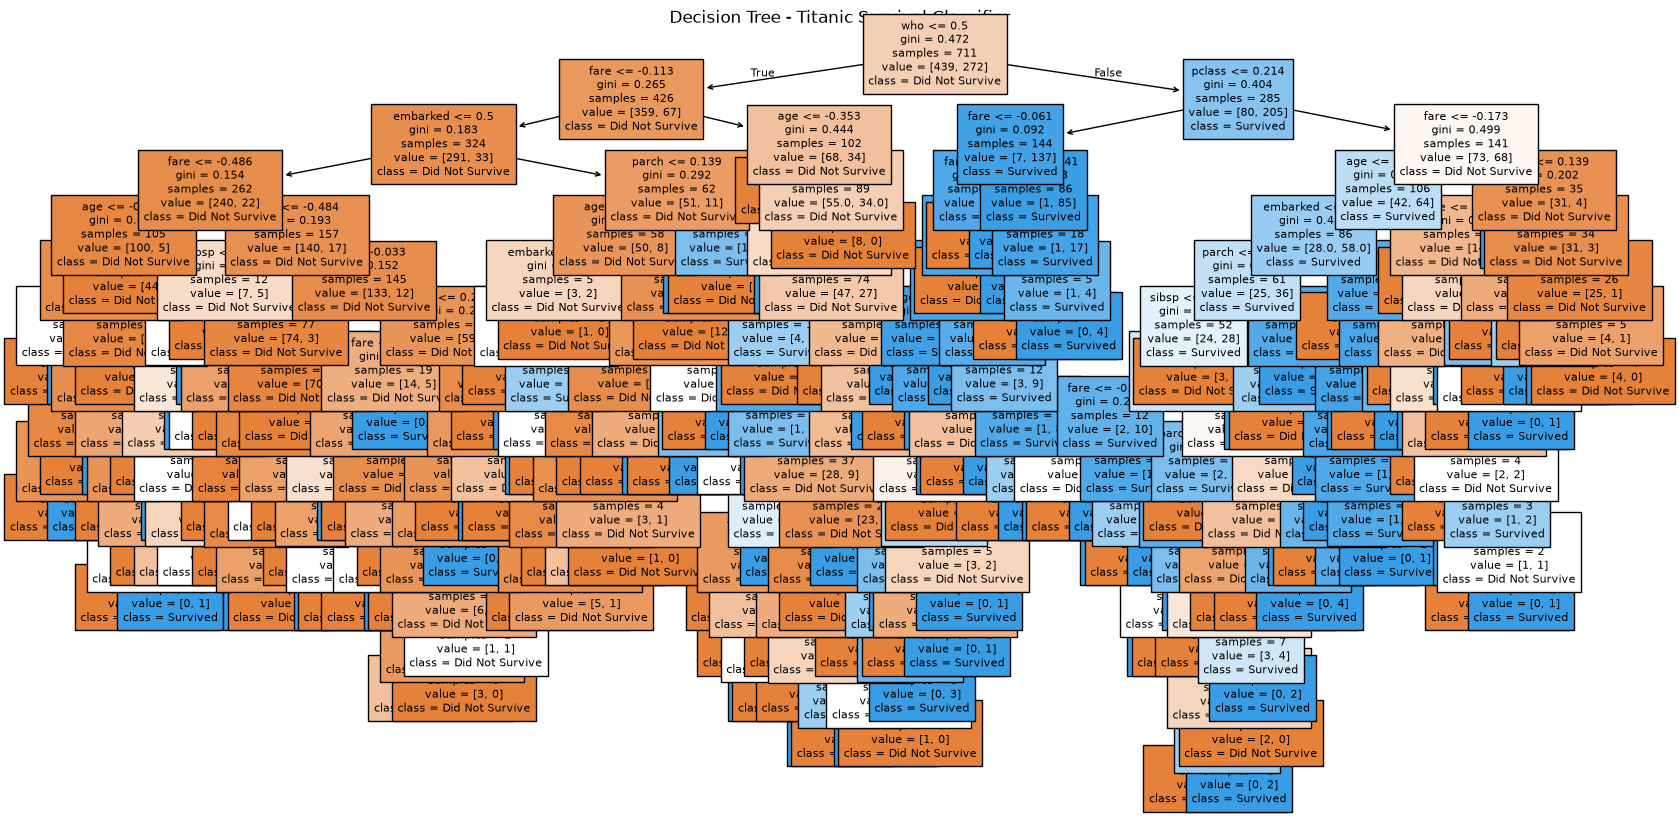

In [35]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    decision_tree,
    feature_names=X_train_processed.columns.tolist(),
    class_names=["Did Not Survive", "Survived"],
    filled=True,
    fontsize=8
)
plt.title("Decision Tree - Titanic Survival Classifier")
plt.show()

In [36]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

models = {
    "Logistic Regression": log_reg,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba)
    })

comparison_table = pd.DataFrame(results).set_index("Model").round(4)
print(comparison_table)

                     Accuracy  Precision  Recall  F1 Score     AUC
Model                                                             
Logistic Regression    0.8258     0.8136  0.7059    0.7559  0.8670
Decision Tree          0.7865     0.7206  0.7206    0.7206  0.7691
Random Forest          0.7921     0.7385  0.7059    0.7218  0.8205


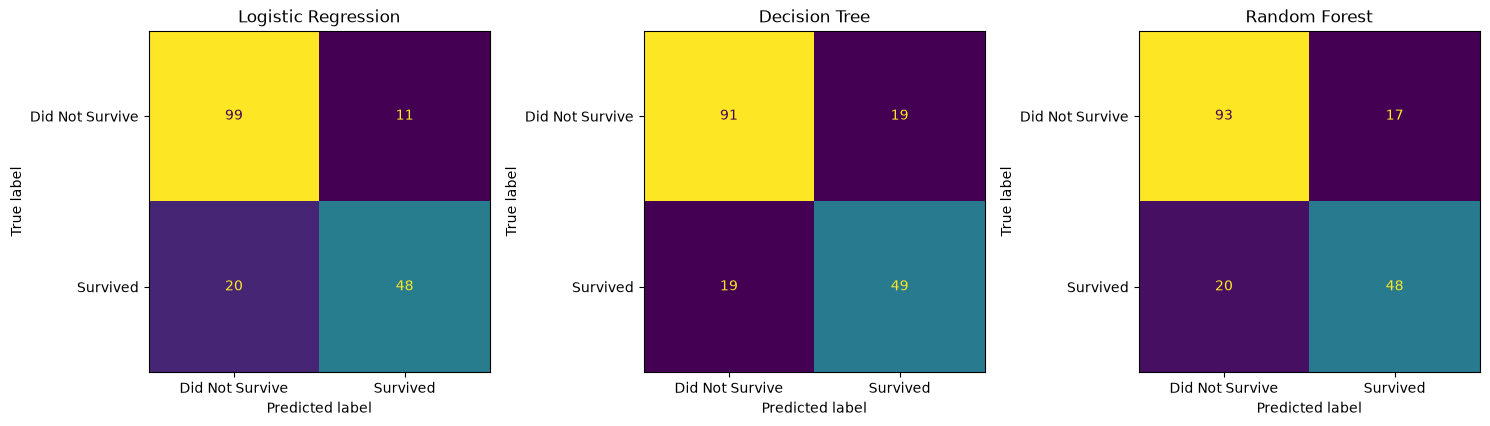

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_processed)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Did Not Survive", "Survived"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

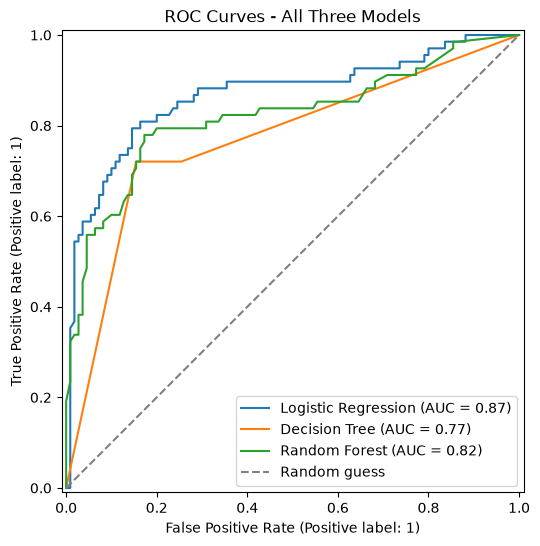

In [38]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 6))

for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test_processed, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
ax.set_title("ROC Curves - All Three Models")
ax.legend()
plt.show()

In [39]:
# value_counts() gives raw counts per class (0 = did not survive, 1 = survived)
class_counts = df["survived"].value_counts()

# normalize=True converts counts into proportions (0-1), then *100 for percentage
class_pct = df["survived"].value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)
print()
print("Class percentages:")
print(class_pct.round(2))

Class counts:
survived
0    549
1    340
Name: count, dtype: int64

Class percentages:
survived
0    61.75
1    38.25
Name: proportion, dtype: float64


In [40]:
from sklearn.linear_model import LogisticRegression

# plain logistic regression, no adjustment for class imbalance at all -
# this is the "do nothing" baseline every other strategy gets compared against
model_baseline = LogisticRegression(random_state=42, max_iter=1000)

# trained on the original, imbalanced training data as-is
model_baseline.fit(X_train_processed, y_train)

# predictions on the untouched test set, same test set used for every variant
# so the three comparisons below are apples-to-apples
y_pred_baseline = model_baseline.predict(X_test_processed)

In [41]:
# class_weight='balanced' doesn't change the data at all - instead it changes
# how much each class "costs" the model to get wrong during training.
# sklearn automatically computes weights inversely proportional to class
# frequency, so misclassifying a survivor (the minority class) is penalized
# more heavily than misclassifying a non-survivor
model_balanced = LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced")

# still trained on the same original imbalanced X_train_processed/y_train -
# only the loss function's internal weighting changes, not the input data
model_balanced.fit(X_train_processed, y_train)

y_pred_balanced = model_balanced.predict(X_test_processed)

In [42]:
from imblearn.over_sampling import SMOTE

# SMOTE = Synthetic Minority Oversampling Technique.
# instead of duplicating existing minority-class rows, it generates new,
# synthetic rows by interpolating between real minority-class examples
# and their nearest neighbors, so the model sees more balanced classes
# without literally repeating the same rows
smote = SMOTE(random_state=42)

# CRITICAL: fit_resample is called on X_train_processed/y_train ONLY.
# if this were applied before the train/test split, or directly to test data,
# synthetic points generated near real test rows could leak test-set
# information into training, making test performance look artificially good.
# keeping SMOTE strictly inside the training fold means the test set stays
# 100% real, untouched data throughout
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

# quick sanity check - class counts should now be roughly equal after SMOTE,
# compared to the original imbalanced counts
print("Before SMOTE - train class counts:", y_train.value_counts().to_dict())
print("After SMOTE - train class counts:", y_train_smote.value_counts().to_dict())

# trained on the SMOTE-balanced training data (not the original imbalanced one)
model_smote = LogisticRegression(random_state=42, max_iter=1000)
model_smote.fit(X_train_smote, y_train_smote)

# still evaluated on the same original, real, untouched test set as (a) and (b) -
# SMOTE never touches this
y_pred_smote = model_smote.predict(X_test_processed)

Before SMOTE - train class counts: {0: 439, 1: 272}
After SMOTE - train class counts: {1: 439, 0: 439}


In [43]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score

# collect each variant's predictions under a readable label,
# so the comparison table below can loop over them cleanly
variants = {
    "(a) Baseline": y_pred_baseline,
    "(b) class_weight=balanced": y_pred_balanced,
    "(c) SMOTE (train only)": y_pred_smote
}

imbalance_results = []
for name, y_pred in variants.items():
    # all three metrics computed against the same y_test every time,
    # so differences in the numbers reflect only the training strategy,
    # not any difference in what they're being evaluated against
    imbalance_results.append({
        "Variant": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

imbalance_comparison = pd.DataFrame(imbalance_results).set_index("Variant").round(4)
print(imbalance_comparison)

                           Precision  Recall  F1 Score
Variant                                               
(a) Baseline                  0.8136  0.7059    0.7559
(b) class_weight=balanced     0.7714  0.7941    0.7826
(c) SMOTE (train only)        0.7727  0.7500    0.7612


In [45]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# oob_score=True must be set at construction time, otherwise oob_score_
# won't be available on the fitted estimator - per the task's explicit note.
# bootstrap=True is required for OOB scoring to work at all (it's the default,
# but stated explicitly here since OOB relies on bootstrap sampling)
rf_base = RandomForestClassifier(
    oob_score=True,
    bootstrap=True,
    random_state=42
)

# parameter grid - GridSearchCV will try every combination of these
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# fit on training data only - GridSearchCV internally cross-validates
# within X_train_processed, never touches X_test_processed
grid_search.fit(X_train_processed, y_train)

print("Best parameter combination:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)
print()

# best_estimator_ is refit on the FULL training set using the best params -
# since oob_score=True was set at construction, this refit estimator has
# its own oob_score_ attribute populated
best_rf = grid_search.best_estimator_
print("Out-of-bag (OOB) score of best estimator:", best_rf.oob_score_)

Best parameter combination: {'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 300}
Best cross-validation accuracy: 0.824170196001182

Out-of-bag (OOB) score of best estimator: 0.8284106891701828


In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# fare becomes the target now, everything else (including survived) becomes a predictor.
# using the same cleaned dataset (df), which already has categoricals label-encoded
X_reg = df.drop(columns=["fare"])
y_reg = df["fare"]

# separate split for this side-task, since the target is different from
# the classification task - not reusing X_train/X_test from before
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

lin_reg = LinearRegression()
lin_reg.fit(X_reg_train, y_reg_train)

y_reg_pred = lin_reg.predict(X_reg_test)

print("Model trained. Coefficients:")
for feature, coef in zip(X_reg.columns, lin_reg.coef_):
    print(f"  {feature}: {coef:.4f}")

Model trained. Coefficients:
  survived: 4.2673
  pclass: -34.7543
  sex: 12.7177
  age: -0.3963
  sibsp: 6.7871
  parch: 12.8201
  embarked: 7.8888
  who: -13.1676
  alone: -1.1835


In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

# adjusted R2 penalizes R2 for the number of predictors used, so adding
# more features doesn't automatically look like an improvement
n = len(y_reg_test)          # number of observations (test set)
p = X_reg_test.shape[1]      # number of predictor features
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print(f"Adjusted R²: {adjusted_r2:.4f}")

MAE:  21.3677
RMSE: 42.4206
R²:   0.3255
Adjusted R²: 0.2894


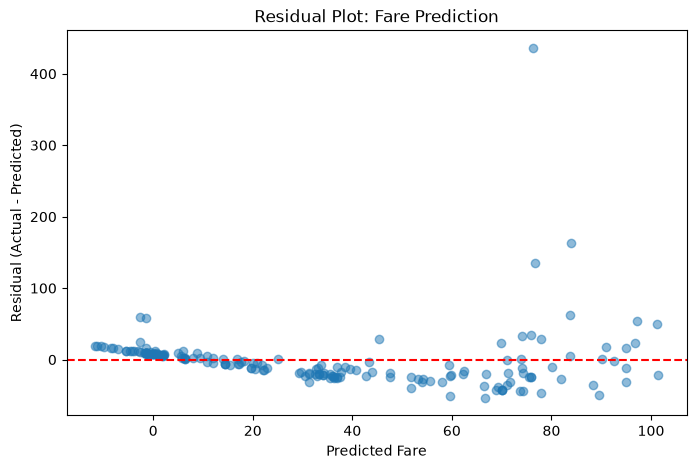

In [48]:
residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_reg_pred, residuals, alpha=0.5)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot: Fare Prediction")
plt.show()

In [49]:
# classification metrics table - already computed in Cell 7 (comparison_table)
classification_table = comparison_table.copy()

# regression metrics as their own single-row table, so it can sit
# alongside the classification table without implying a shared scale
regression_table = pd.DataFrame({
    "MAE": [mae],
    "RMSE": [rmse],
    "R²": [r2],
    "Adjusted R²": [adjusted_r2]
}, index=["Linear Regression (fare)"])

print("=" * 60)
print("Classification Models - Predicting Survival")
print("=" * 60)
print(classification_table)

print()
print("=" * 60)
print("Regression Model - Predicting Fare")
print("=" * 60)
print(regression_table)

Classification Models - Predicting Survival
                     Accuracy  Precision  Recall  F1 Score     AUC
Model                                                             
Logistic Regression    0.8258     0.8136  0.7059    0.7559  0.8670
Decision Tree          0.7865     0.7206  0.7206    0.7206  0.7691
Random Forest          0.7921     0.7385  0.7059    0.7218  0.8205

Regression Model - Predicting Fare
                               MAE       RMSE        R²  Adjusted R²
Linear Regression (fare)  21.36774  42.420579  0.325508     0.289375


In [50]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# reload the RAW cleaned CSV fresh - categories still as original text
# (e.g. "male"/"female"), not the manually label-encoded version used
# earlier in this notebook. this is essential: the saved pipeline must
# accept genuinely raw, unprocessed new data
raw_df = pd.read_csv("titanic_clean.csv")

X_raw = raw_df.drop(columns=["survived"])
y_raw = raw_df["survived"]

X_raw_train, X_raw_test, y_raw_train, y_raw_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

categorical_cols = ["sex", "embarked", "who", "alone"]
numeric_cols = ["pclass", "age", "sibsp", "parch", "fare"]

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    # handle_unknown + unknown_value: if new input contains a category
    # never seen during training (e.g. a typo like "women" instead of
    # "woman"), encode it as -1 instead of crashing the whole pipeline
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ("cat", categorical_pipeline, categorical_cols),
    ("num", numeric_pipeline, numeric_cols)
])

# full pipeline = preprocessing + best-performing model (Logistic
# Regression, per Task 14's recommendation) combined as ONE object
full_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000))
])

# fit end-to-end on RAW training data - the pipeline itself handles
# imputing, encoding, and scaling internally
full_pipeline.fit(X_raw_train, y_raw_train)

test_accuracy = full_pipeline.score(X_raw_test, y_raw_test)
print(f"Full pipeline test accuracy: {test_accuracy:.4f}")

# save the ENTIRE pipeline (preprocessing + model) as one artifact -
# NOT just the bare classifier, so it's usable end-to-end on new raw data
joblib.dump(full_pipeline, "titanic_survival_pipeline.joblib")
print("Saved complete pipeline to titanic_survival_pipeline.joblib")

Full pipeline test accuracy: 0.8146
Saved complete pipeline to titanic_survival_pipeline.joblib


In [51]:
loaded_pipeline = joblib.load("titanic_survival_pipeline.joblib")

print("Enter passenger details to predict survival:")
print()

pclass = int(input("Passenger class (1, 2, or 3): "))
sex = input("Sex (male/female): ").strip().lower()
age = float(input("Age: "))
sibsp = int(input("Number of siblings/spouses aboard: "))
parch = int(input("Number of parents/children aboard: "))
fare = float(input("Fare paid: "))
embarked = input("Port of embarkation (S/C/Q): ").strip().upper()
who = input("Category (man/woman/child): ").strip().lower()
alone = input("Traveling alone? (yes/no): ").strip().lower() == "yes"

raw_sample = pd.DataFrame([{
    "pclass": pclass,
    "sex": sex,
    "age": age,
    "sibsp": sibsp,
    "parch": parch,
    "fare": fare,
    "embarked": embarked,
    "who": who,
    "alone": alone
}])

prediction = loaded_pipeline.predict(raw_sample)
prediction_proba = loaded_pipeline.predict_proba(raw_sample)

print()
print("Input received:")
print(raw_sample)
print()
outcome = "SURVIVED" if prediction[0] == 1 else "DID NOT SURVIVE"
print(f"Prediction: {outcome}")
print(f"Survival probability: {prediction_proba[0][1]:.4f}")
print(f"Did-not-survive probability: {prediction_proba[0][0]:.4f}")

Enter passenger details to predict survival:




Input received:
   pclass   sex   age  sibsp  parch  fare embarked  who  alone
0       1  male  45.0      1      1  50.0        Q  man  False

Prediction: DID NOT SURVIVE
Survival probability: 0.3448
Did-not-survive probability: 0.6552
